In [124]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [125]:
def leer_csv(ruta_archivo):
    """
    Función para leer un archivo CSV con cabecera. Los datos están separados por comas y están todos (valores y texto) entre comillas " "

    """
    try:
        df = pd.read_csv(
            ruta_archivo,
            sep=',',          # Indicamos que el separador es la coma
            header=0,         # Indicamos que la fila 0 (la primera) tiene las etiquetas
            quotechar='"'     # Le decimos que ignore las comas que estén dentro de las comillas
        )
        print("¡Archivo CSV cargado con éxito!")
        return df
        
    except FileNotFoundError:
        print(f"Error: No se ha encontrado el archivo en la ruta '{ruta_archivo}'.")
        return None
    except Exception as e:
        print(f"Ocurrió un error inesperado al leer el CSV: {e}")
        return None



In [126]:
def running_avg(x, w):
    cumsum = np.cumsum(np.insert(x, 0, 0)) #introduce un 0 al principio de la suma acumulativa para facilitar el cálculo del promedio
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - w + 1)
        count = i - start + 1
        out[i] = (cumsum[i+1] - cumsum[start]) / count
    return out

In [127]:
colores = {
    'Swin': '#C72A66',     # Frambuesa oscuro (test-model_082337)
    'VGG': '#B16A3C',      # Bronce / Marrón cobrizo (test-model_080952)
    'ResNet': '#1E8675',   # Verde azulado / Teal (test-model_060949)
    'ConvNeXt': "#7D1485"  # Fucsia vibrante (test-model_051324)
}

Primera gráfica: RMSE de los datos de validación para el conjunto de día

In [128]:
rmse_val_day=leer_csv('rmse_valheight_day.csv')


etiquetas = rmse_val_day.columns.tolist()
print("Las etiquetas del archivo rmse_valheight_day.csv son:")
for etiqueta in etiquetas:
    print(f" -> '{etiqueta}'")

epocas=rmse_val_day['Step']
epocas=round(epocas/(epocas.iloc[-1]/100))


¡Archivo CSV cargado con éxito!
Las etiquetas del archivo rmse_valheight_day.csv son:
 -> 'Step'
 -> 'test-model_082337 - Val RMSE Validación (metros)'
 -> 'test-model_082337 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_082337 - Val RMSE Validación (metros)__MAX'
 -> 'test-model_080952 - Val RMSE Validación (metros)'
 -> 'test-model_080952 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_080952 - Val RMSE Validación (metros)__MAX'
 -> 'test-model_060949 - Val RMSE Validación (metros)'
 -> 'test-model_060949 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_060949 - Val RMSE Validación (metros)__MAX'
 -> 'test-model_051324 - Val RMSE Validación (metros)'
 -> 'test-model_051324 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_051324 - Val RMSE Validación (metros)__MAX'


<function matplotlib.pyplot.show(close=None, block=None)>

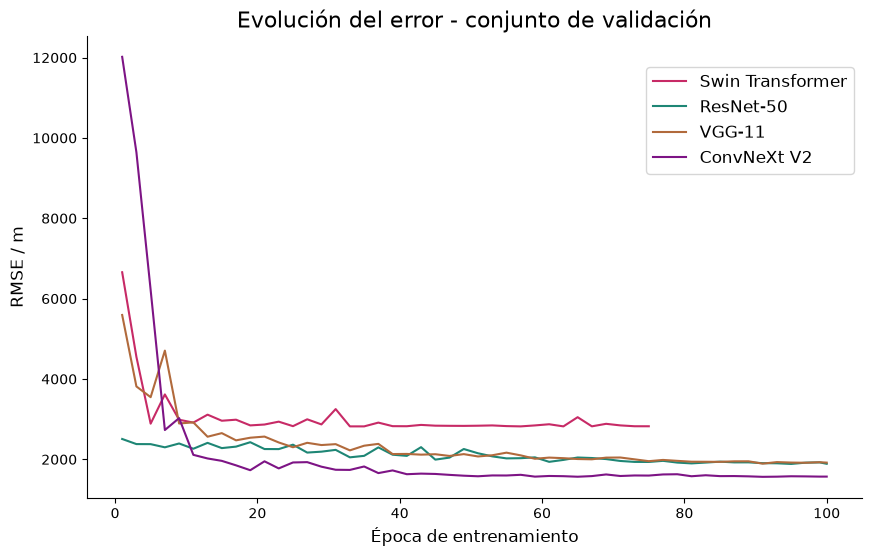

In [129]:
plt.figure(figsize=(10,6))

plt.plot(epocas, rmse_val_day['test-model_082337 - Val RMSE Validación (metros)'], label='Swin Transformer', linewidth=1.5, color=colores['Swin'])
plt.plot(epocas, rmse_val_day['test-model_060949 - Val RMSE Validación (metros)'], label='ResNet-50', linewidth=1.5, color=colores['ResNet'])
plt.plot(epocas, rmse_val_day['test-model_080952 - Val RMSE Validación (metros)'], label='VGG-11', linewidth=1.5, color=colores['VGG'])
plt.plot(epocas, rmse_val_day['test-model_051324 - Val RMSE Validación (metros)'], label='ConvNeXt V2', linewidth=1.5, color=colores['ConvNeXt'])

plt.xlabel('Época de entrenamiento', fontsize=12)
plt.ylabel('RMSE / m', fontsize=12)
plt.title('Evolución del error - conjunto de validación', fontsize=16)
plt.legend(fontsize=12,  bbox_to_anchor=(1.0, 0.95))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show

In [130]:
rmse_train_day=leer_csv('rmse_trainheight_day.csv')


etiquetas2 = rmse_train_day.columns.tolist()
print("Las etiquetas del archivo rmse_trainheight_day.csv son:")
for etiqueta in etiquetas2:
    print(f" -> '{etiqueta}'")

epocas=rmse_train_day['Step']
epocas=epocas/(epocas.iloc[-1]/100)
print(epocas)


¡Archivo CSV cargado con éxito!
Las etiquetas del archivo rmse_trainheight_day.csv son:
 -> 'Step'
 -> 'test-model_082337 - Train RMSE (meters)'
 -> 'test-model_082337 - Train RMSE (meters)__MIN'
 -> 'test-model_082337 - Train RMSE (meters)__MAX'
 -> 'test-model_080952 - Train RMSE (meters)'
 -> 'test-model_080952 - Train RMSE (meters)__MIN'
 -> 'test-model_080952 - Train RMSE (meters)__MAX'
 -> 'test-model_060949 - Train RMSE (meters)'
 -> 'test-model_060949 - Train RMSE (meters)__MIN'
 -> 'test-model_060949 - Train RMSE (meters)__MAX'
 -> 'test-model_051324 - Train RMSE (meters)'
 -> 'test-model_051324 - Train RMSE (meters)__MIN'
 -> 'test-model_051324 - Train RMSE (meters)__MAX'
0          0.00381
1          0.01143
2          0.01905
3          0.02667
4          0.03429
           ...    
12312     99.95428
12313     99.96190
12314     99.98476
12315     99.99238
12316    100.00000
Name: Step, Length: 12317, dtype: float64


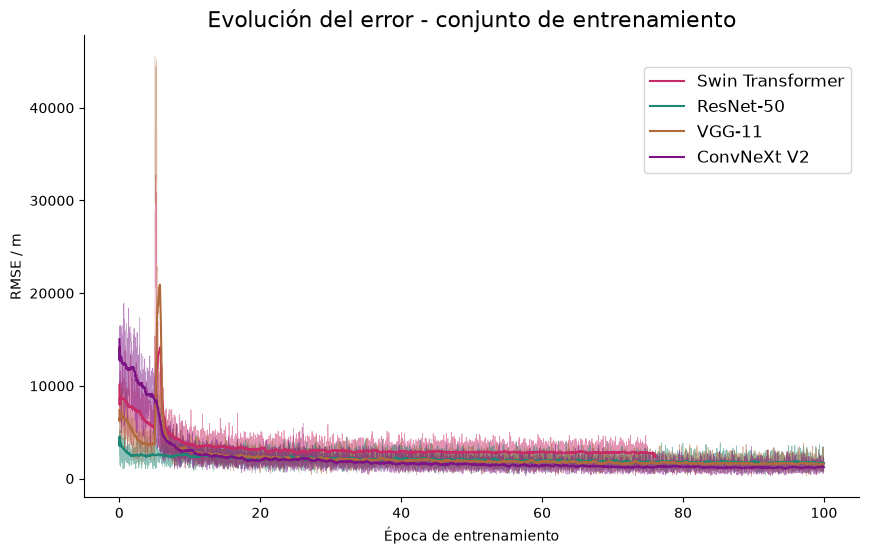

In [131]:
plt.figure(figsize=(10,6))

everyN=1
window=100

# 1. Extraemos los datos crudos de todos los modelos
swin = rmse_train_day['test-model_082337 - Train RMSE (meters)'][::everyN]
resnet = rmse_train_day['test-model_060949 - Train RMSE (meters)'][::everyN]
vgg = rmse_train_day['test-model_080952 - Train RMSE (meters)'][::everyN]
convnext = rmse_train_day['test-model_051324 - Train RMSE (meters)'][::everyN]


swin_avg = swin.rolling(window=window, min_periods=1).mean()
resnet_avg = resnet.rolling(window=window, min_periods=1).mean()
vgg_avg = vgg.rolling(window=window, min_periods=1).mean()
convnext_avg = convnext.rolling(window=window, min_periods=1).mean()


plt.plot(epocas[::everyN], swin, color=colores['Swin'], linewidth=0.5, alpha=0.5)
plt.plot(epocas[::everyN], resnet, color=colores['ResNet'], linewidth=0.5, alpha=0.5)
plt.plot(epocas[::everyN], vgg, color=colores['VGG'], linewidth=0.5, alpha=0.5)
plt.plot(epocas[::everyN], convnext, color=colores['ConvNeXt'], linewidth=0.5, alpha=0.5)


plt.plot(epocas[::everyN], swin_avg, label='Swin Transformer', color=colores['Swin'], linewidth=1.5)
plt.plot(epocas[::everyN], resnet_avg, label='ResNet-50', color=colores['ResNet'], linewidth=1.5)
plt.plot(epocas[::everyN], vgg_avg, label='VGG-11', color=colores['VGG'], linewidth=1.5)
plt.plot(epocas[::everyN], convnext_avg, label='ConvNeXt V2', color=colores['ConvNeXt'], linewidth=1.5)

plt.xlabel('Época de entrenamiento')
plt.ylabel('RMSE / m')
plt.title('Evolución del error - conjunto de entrenamiento', fontsize=16)
plt.legend(fontsize=12, bbox_to_anchor=(1.0, 0.95))

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()